# Y-axis orientation — every case, one rule

NetCDF files store their rows in whatever order the producer wrote them. GDAL's raster convention is fixed:
**row 0 is the north edge** (a negative Y pixel size) and **column 0 is the west edge**. Whenever a file stores its
rows south→north — the most common NetCDF layout — `pyramids` must reverse them on read, and when it doesn't, it must
leave them alone. Getting this wrong doesn't crash: it hands you a **silently mirrored raster** whose values are wrong
at every coordinate you sample ([#705](https://github.com/serapeum-org/pyramids/issues/705)).

One rule decides every case: read the Y coordinate variable **with its `scale_factor` / `add_offset` applied**, then

> **flip the rows iff the scaled coordinate ascends** (row 0 stored at the south edge).

The CRS never enters the decision, and the same rule applies to the X axis (`col 0 = west`). This notebook walks the
full matrix with real files:

| | ascending (→ **flip**) | descending (→ **keep**) |
|---|---|---|
| **geographic** | NOAH precipitation | NCEP `air` temperature |
| **geostationary** | *(no known producer)* | GOES-16 ABI — raw ascends, **scaled descends** |
| **projected** | UTM, written bottom-up | UTM, written top-down |

The geostationary row is the reason the rule reads the *scaled* coordinate: GOES packs its scan angle as `int16` with a
**negative** `scale_factor`, so the raw storage order and the physical direction disagree — the one case that separates
the correct rule from the plausible-but-wrong ones.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
from osgeo import gdal, osr

from pyramids.netcdf import NetCDF

gdal.UseExceptions()
DATA = Path('../../../../examples/data/netcdf/samples')

2026-07-11 01:15:41 | INFO | pyramids.base.config | Logging is configured.


## A helper to peek at the stored Y axis

Before opening each file with `pyramids`, we look at what is actually stored, using GDAL's multidimensional API
directly: the **raw** values of the Y coordinate variable, and the same values with `scale_factor` / `add_offset`
applied (`GetUnscaled()`). The verdict line is the rule this notebook is about.

In [2]:
def y_axis_report(path, variable):
    """Print the raw and scaled endpoints of a variable's Y coordinate, and the flip verdict."""
    root = gdal.OpenEx(str(path), gdal.OF_MULTIDIM_RASTER).GetRootGroup()
    dims = root.OpenMDArray(variable).GetDimensions()
    y_coord = dims[len(dims) - 2].GetIndexingVariable()
    raw = np.asarray(y_coord.ReadAsArray())
    scaled = np.asarray(y_coord.GetUnscaled().ReadAsArray())
    ascends = scaled[0] < scaled[-1]
    print(f'raw    y: {raw[0]:>12.6g} .. {raw[-1]:>12.6g}')
    print(f'scaled y: {scaled[0]:>12.6g} .. {scaled[-1]:>12.6g}   (physically '
          f'{"ascends" if ascends else "descends"})')
    print('verdict : rows are', 'FLIPPED to north-up' if ascends else 'KEPT as stored')

## Case 1 — geographic, ascending latitude (→ flip)

The classic NetCDF layout: latitude stored **south→north**, so row 0 of the array is the *south* edge — upside-down by
raster convention. This NOAH precipitation file is a real global 0.5° grid stored that way. The report shows an
ascending coordinate (raw and scaled agree — the coordinate is not packed), so `pyramids` reverses the rows on read.

In [3]:
noah_path = DATA / 'cf__6v__1d2-2d4__geog__y-asc.nc'
y_axis_report(noah_path, 'Band1')

raw    y:       -89.75 ..        89.75
scaled y:       -89.75 ..        89.75   (physically ascends)
verdict : rows are FLIPPED to north-up


Open it and check what came back: the geotransform must be **north-up** (negative Y pixel size, origin at the
north edge), regardless of the storage order.

In [4]:
noah = NetCDF.read_file(noah_path).get_variable('Band1')
gt = noah.geotransform
print(f'origin (top-left) : ({gt[0]:.2f}, {gt[3]:.2f})')
print(f'pixel height      : {gt[5]:.2f}   (negative = row 0 is the north edge)')

origin (top-left) : (0.00, 90.00)
pixel height      : -0.50   (negative = row 0 is the north edge)


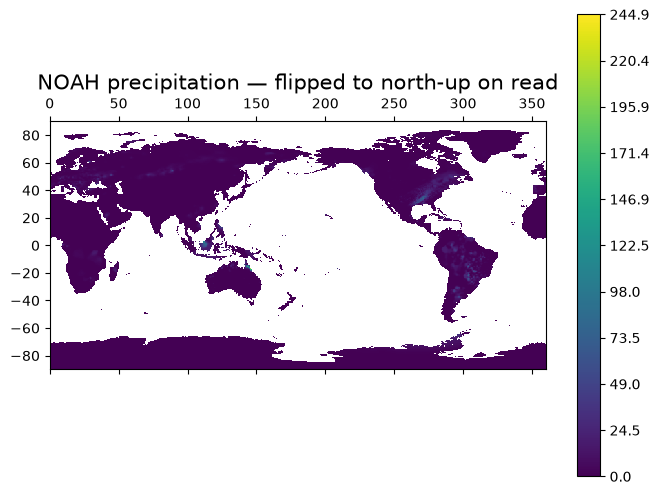

In [5]:
glyph = noah.plot(title='NOAH precipitation — flipped to north-up on read', cmap='viridis')

The map is right-side-up — the Arctic at the top, Antarctica at the bottom. Had the rows been left in storage
order under this north-up geotransform, the continents would render vertically mirrored.

## Case 2 — geographic, descending latitude (→ keep)

Some producers already write north-first. This NCEP reanalysis air-temperature file (int16-packed, COARDS) stores
latitude 75°→15° — row 0 is already the north edge, so `pyramids` must **not** touch it.

In [6]:
air_path = DATA / 'coards__4v__1d3-3d1__y-desc.nc'
y_axis_report(air_path, 'air')

raw    y:           75 ..           15
scaled y:           75 ..           15   (physically descends)
verdict : rows are KEPT as stored


pixel height: -2.50   (already north-up, rows kept)


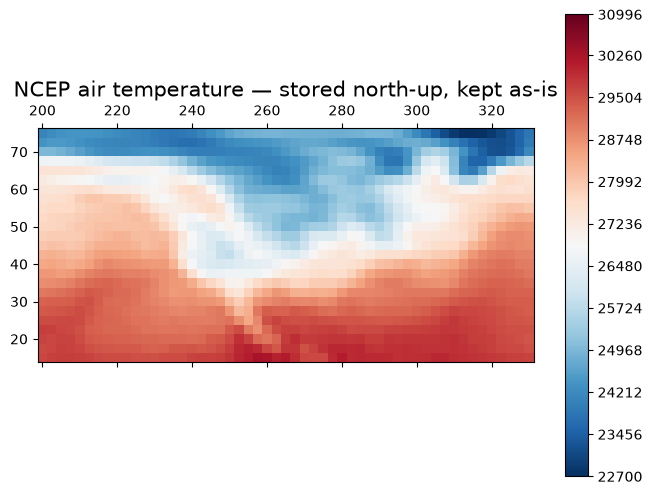

In [7]:
air = NetCDF.read_file(air_path).get_variable('air')
print(f'pixel height: {air.geotransform[5]:.2f}   (already north-up, rows kept)')
glyph = air.plot(title='NCEP air temperature — stored north-up, kept as-is', cmap='RdBu_r')

North America sits the right way up without any flip. A rule that blindly reversed every NetCDF — or one keyed
on "geographic files are usually south-up" — would have mirrored this one.

## Case 3 — geostationary: the #705 trap (raw ascends, scaled descends → keep)

This is a real GOES-16 ABI granule (Cloud & Moisture Imagery, mesoscale sector). Its `y` coordinate is the satellite's
**radian scan angle**, packed as `int16` with a **negative** `scale_factor` ≈ −5.6e-05. Watch the report: the **raw**
values ascend while the **scaled** (physical) values descend.

| signal | direction | trustworthy? |
|---|---|---|
| raw storage order | ascends | **no** — reversed by the negative `scale_factor` |
| view geotransform (`gt[5]`) | positive (says "flip") | **no** — GDAL derives it from the raw values |
| scaled coordinate (`GetUnscaled()`) | descends | **yes** — the physical axis |

Deciding from either of the first two signals flips an array that is already north-up — exactly the silent vertical
mirror reported in [#705](https://github.com/serapeum-org/pyramids/issues/705).

In [8]:
goes_path = DATA / 'cf__9v__1d7-2d2__geos__y-desc.nc'
y_axis_report(goes_path, 'CMI')

raw    y:            0 ..          499
scaled y:     0.041972 ..     0.014028   (physically descends)
verdict : rows are KEPT as stored


Open the variable and verify against an independent reference: GDAL's classic netCDF driver applies the
coordinate scaling correctly, so `pyramids`' pixels must match it byte-for-byte — not be its upside-down copy.

In [9]:
goes = NetCDF.read_file(goes_path).get_variable('CMI')
classic = gdal.Open(f'NETCDF:"{goes_path}":CMI').ReadAsArray()
print('matches the classic driver     :', np.array_equal(goes.read_array(), classic))
print('matches its vertical mirror    :', np.array_equal(goes.read_array(), classic[::-1, :]))
print(f'geotransform (metres)          : pixel = {goes.geotransform[1]:,.0f} m')

2026-07-11 01:15:44 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


2026-07-11 01:15:44 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


matches the classic driver     : True
matches its vertical mirror    : False
geotransform (metres)          : pixel = 2,004 m


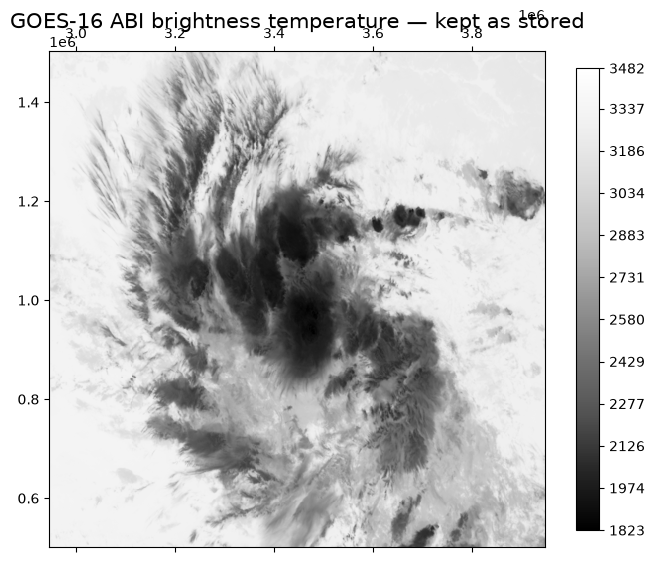

In [10]:
glyph = goes.plot(title='GOES-16 ABI brightness temperature — kept as stored', cmap='Greys_r')

The cloud field renders in its true orientation. Before the fix, this array was flipped (the raw order and the
geotransform sign both said "ascending"), so every coordinate a user sampled after `to_crs(4326)` returned the value
from the mirrored row — plausible-looking, silently wrong.

## Case 4 — projected CRS, both directions

No public producer we know of ships a projected-CRS NetCDF with an *ascending* Y, so we create both directions with
GDAL itself: the netCDF driver's `WRITE_BOTTOMUP` option controls the storage order of the same UTM grid. The pixel
values are a simple gradient — 0 in the **north-west** corner, increasing southward and eastward — so the orientation
is visible in the array itself.

In [11]:
def write_utm(path, bottom_up):
    """Write an 8x6 UTM-36N gradient raster to netCDF, stored bottom-up or top-down."""
    src = gdal.GetDriverByName('MEM').Create('', 8, 6, 1, gdal.GDT_Float32)
    srs = osr.SpatialReference()
    srs.ImportFromEPSG(32636)
    src.SetProjection(srs.ExportToWkt())
    src.SetGeoTransform((500000.0, 100.0, 0.0, 4000000.0, 0.0, -100.0))
    src.GetRasterBand(1).WriteArray(np.arange(48, dtype=np.float32).reshape(6, 8))
    options = [f"WRITE_BOTTOMUP={'YES' if bottom_up else 'NO'}"]
    gdal.Translate(str(path), src, format='netCDF', creationOptions=options)

work_dir = Path(tempfile.mkdtemp())
utm_ascending_path = work_dir / 'utm_ascending.nc'
utm_descending_path = work_dir / 'utm_descending.nc'
write_utm(utm_ascending_path, bottom_up=True)
write_utm(utm_descending_path, bottom_up=False)

Both files hold the identical grid; only the row order on disk differs. The rule reads the projected `y`
coordinate (metres, unpacked — raw and scaled agree) and normalizes both to the same north-up raster.

In [12]:
print('-- stored bottom-up (ascending y) --')
y_axis_report(utm_ascending_path, 'Band1')
print()
print('-- stored top-down (descending y) --')
y_axis_report(utm_descending_path, 'Band1')

-- stored bottom-up (ascending y) --
raw    y:  3.99945e+06 ..  3.99995e+06
scaled y:  3.99945e+06 ..  3.99995e+06   (physically ascends)
verdict : rows are FLIPPED to north-up

-- stored top-down (descending y) --
raw    y:  3.99995e+06 ..  3.99945e+06
scaled y:  3.99995e+06 ..  3.99945e+06   (physically descends)
verdict : rows are KEPT as stored


In [13]:
ascending = NetCDF.read_file(utm_ascending_path).get_variable('Band1')
descending = NetCDF.read_file(utm_descending_path).get_variable('Band1')
print('both reads identical      :', np.array_equal(ascending.read_array(), descending.read_array()))
print('row 0 after reading       :', ascending.read_array()[0].tolist())

both reads identical      : True
row 0 after reading       : [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]


Row 0 comes back `[0, 1, ... 7]` — the gradient's northern edge — from **both** files. GDAL's own classic netCDF
driver only auto-corrects a recognised *geographic latitude*; a projected `projection_y_coordinate` would have slipped
through a CRS-based rule, which is why the decision keys off the coordinate values alone.

## Case 5 — the X axis: descending longitude (→ columns reversed)

The same rule applies to columns, mirrored: **column 0 must be the west edge**. A longitude stored east→west is legal
CF, though no known producer writes one. We build it the same way — an east-origin geotransform — and check that both
the array and the bounding box come back west-first.

In [14]:
x_desc_path = work_dir / 'lon_descending.nc'
src = gdal.GetDriverByName('MEM').Create('', 5, 4, 1, gdal.GDT_Float32)
srs = osr.SpatialReference()
srs.ImportFromEPSG(4326)
src.SetProjection(srs.ExportToWkt())
src.SetGeoTransform((30.0, -2.0, 0.0, 10.0, 0.0, -1.0))   # origin at the EAST edge, lon 30 -> 20
src.GetRasterBand(1).WriteArray(np.arange(20, dtype=np.float32).reshape(4, 5))
written = gdal.Translate(str(x_desc_path), src, format='netCDF', creationOptions=['WRITE_BOTTOMUP=NO'])
written = None   # close the writer so the file is flushed

In [15]:
x_desc = NetCDF.read_file(x_desc_path).get_variable('Band1')
print('bbox [west, south, east, north]:', [float(round(v, 1)) for v in x_desc.bbox])
print('row 0 after reading            :', x_desc.read_array()[0].tolist())
print('pixel width                    :', x_desc.geotransform[1], '(positive = col 0 is the west edge)')

bbox [west, south, east, north]: [20.0, 6.0, 30.0, 10.0]
row 0 after reading            : [4.0, 3.0, 2.0, 1.0, 0.0]
pixel width                    : 2.0 (positive = col 0 is the west edge)


The stored row 0 was `[0, 1, 2, 3, 4]` east-first; it reads back `[4, 3, 2, 1, 0]` under a positive pixel width
and the true extent `[20, 6, 30, 10]`. Without the X rule this file returned mirrored columns under a bounding box
shifted a full grid-width east.

## One rule, three read paths

The decision lives in one place (`pyramids.netcdf._mdim`) and every read path consumes it — the eager
`get_variable().read_array()`, the chunked/dask `read_array(chunks=...)`, and the library's internal reads. The three
must agree with each other and with GDAL's classic driver for every case above; when the rule lived only in the eager
path, chunked geostationary reads were still mirrored.

In [16]:
rows = []
for path, variable in [(noah_path, 'Band1'), (air_path, 'air'), (goes_path, 'CMI')]:
    eager = np.asarray(NetCDF.read_file(path).get_variable(variable).read_array())
    lazy = np.asarray(NetCDF.read_file(path).get_variable(variable).read_array(chunks='auto'))
    classic = gdal.Open(f'NETCDF:"{path}":{variable}').ReadAsArray()
    rows.append((path.name, variable,
                 np.array_equal(lazy, eager), np.array_equal(eager, np.asarray(classic))))
print(f'{"file":42s} {"variable":9s} {"lazy == eager":14s} eager == classic driver')
for name, var, lazy_ok, classic_ok in rows:
    print(f'{name:42s} {var:9s} {str(lazy_ok):14s} {classic_ok}')

2026-07-11 01:15:45 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


2026-07-11 01:15:45 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


2026-07-11 01:15:45 | WARNING | pyramids.base.config.gdal | GDAL[1] Unhandled X/Y axis unit rad. SRS will ignore axis unit and be likely wrong.


file                                       variable  lazy == eager  eager == classic driver
cf__6v__1d2-2d4__geog__y-asc.nc            Band1     True           True
coards__4v__1d3-3d1__y-desc.nc             air       True           True
cf__9v__1d7-2d2__geos__y-desc.nc           CMI       True           True


## Takeaway

- GDAL's raster convention is **row 0 = north, col 0 = west**; NetCDF files store rows and columns in whatever order
  the producer chose.
- `pyramids` normalizes on read with one CRS-agnostic rule per axis: **flip iff the scale/offset-applied coordinate
  runs against the convention.**
- The raw storage order and the view's geotransform sign are *not* safe signals — a negative `scale_factor`
  (geostationary scan angles) reverses both relative to the physical axis, which is how
  [#705](https://github.com/serapeum-org/pyramids/issues/705) shipped a silently mirrored raster.
- The rule holds across geographic, projected, and geostationary CRSs, on both axes, and on every read path — eager,
  chunked, and internal.

**Go deeper:** the fixture catalog documents each file's orientation in its name (`y-asc` / `y-desc`, named for the
*scaled* direction), and `docs/testing/netcdf/tests.md` maps the test matrix that pins all of this down.